In [1]:
import torch 
import os
import numpy as np
import torch.nn.functional as F
import pickle

from torch.utils.data import Dataset, random_split
from torch import nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# download dataset and split train and test set

cf10_training_data = datasets.CIFAR10(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 

cf10_test_data = datasets.CIFAR10(root = 'Data', train = False, download= True, transform = transforms.ToTensor())


cf100_training_data = datasets.CIFAR100(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 
cf100_test_data = datasets.CIFAR100(root = 'Data', train = False, download= True, transform = transforms.ToTensor())

In [4]:
base_folder = cf100_training_data.base_folder
root = cf100_training_data.root
file_path = os.path.join(root, base_folder, 'train')

with open(file_path, 'rb')as f:
    entry =pickle.load(f, encoding = 'latin1')
    cf100_training_data.targets = entry['coarse_labels']

file_path_test = os.path.join(root, base_folder, 'test')
with open(file_path_test, 'rb') as f:
    entry_test = pickle.load(f, encoding='latin1')
    cf100_test_data.targets = entry_test['coarse_labels']

In [5]:
#Splitting Logic
train_size = 40000
val_size = 10000

# print(len(cf100_training_data))

cf10_train_subset, cf10_val_subset = random_split(cf10_training_data, [train_size,val_size])
#cf100_val_data = random_split(cf100_training_data, [len(cf100_training_data)*0.8, len(cf100_training_data)*0.2])

In [6]:
print(1)
training_loader = torch.utils.data.DataLoader(cf10_train_subset, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(cf10_val_subset, batch_size=32, shuffle=False)
#testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

1


In [7]:
class LesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X
        
model_1 = LesNet().to(device)

In [8]:
# model 2

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        #add dropuot 
        #self.dropout = nn.Dropout2d(p = 0.3) # 30% chance to be 0

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 
        
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_2 = Model2().to(device)

In [9]:
# model 3

class Model3(nn.Module): #Batch Normalization
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3 = Model3().to(device)

In [10]:
#Train for each epoch
def train_one_epoch(model, loader,optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, label in loader:
        if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    average_loss = running_loss / len(loader)
    
    accuracy = correct/ total * 100
    return average_loss, accuracy

In [11]:
#validate each epoch
def validate(model, loader, criterion):
    model.eval() #Set model to eval mode 
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, label in loader:
            if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, label)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += label.size(0)
            correct += predicted.eq(label).sum().item()

        average_loss = running_loss / len(loader)
        accuracy = correct/ total * 100
        return average_loss, accuracy

            

In [12]:
def run_full_training_validate(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [13]:
history_1 = run_full_training_validate(model_1, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.6780972291946412, Training Accuracy: 39.2975
Epoch 1, Validation Loss : 1.4483028966397904, Validation Accuracy: 48.19
Epoch 2, Training Loss : 1.39297671251297, Training Accuracy: 50.1225
Epoch 2, Validation Loss : 1.329094923723239, Validation Accuracy: 52.849999999999994
Epoch 3, Training Loss : 1.2784948902130127, Training Accuracy: 54.347500000000004
Epoch 3, Validation Loss : 1.291065966740203, Validation Accuracy: 54.11
Epoch 4, Training Loss : 1.2001079535484314, Training Accuracy: 57.19499999999999
Epoch 4, Validation Loss : 1.3062447882688846, Validation Accuracy: 53.65
Epoch 5, Training Loss : 1.1383117089748382, Training Accuracy: 59.540000000000006
Epoch 5, Validation Loss : 1.2693662536791719, Validation Accuracy: 55.36
Epoch 6, Training Loss : 1.0862819855213166, Training Accuracy: 61.502500000000005
Epoch 6, Validation Loss : 1.1960567616807005, Validation Accuracy: 58.099999999999994
Epoch 7, Training

In [14]:
history_2 = run_full_training_validate(model_2, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.9602939213752746, Training Accuracy: 28.27
Epoch 1, Validation Loss : 1.794109627461662, Validation Accuracy: 35.54
Epoch 2, Training Loss : 1.734797620010376, Training Accuracy: 37.3825
Epoch 2, Validation Loss : 1.6993155707947363, Validation Accuracy: 38.78
Epoch 3, Training Loss : 1.6640789249420167, Training Accuracy: 40.044999999999995
Epoch 3, Validation Loss : 1.6611704571178545, Validation Accuracy: 39.800000000000004
Epoch 4, Training Loss : 1.6197363297462464, Training Accuracy: 41.055
Epoch 4, Validation Loss : 1.639932021927148, Validation Accuracy: 40.46
Epoch 5, Training Loss : 1.5915588042259217, Training Accuracy: 42.655
Epoch 5, Validation Loss : 1.6130457895632369, Validation Accuracy: 42.05
Epoch 6, Training Loss : 1.5493014217376708, Training Accuracy: 43.9375
Epoch 6, Validation Loss : 1.5885894968867682, Validation Accuracy: 43.03
Epoch 7, Training Loss : 1.5350470769405364, Training Accuracy: 4

In [15]:
history_3 = run_full_training_validate(model_3, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.5532316909790038, Training Accuracy: 44.080000000000005
Epoch 1, Validation Loss : 1.346955236916344, Validation Accuracy: 51.959999999999994
Epoch 2, Training Loss : 1.2569022531032563, Training Accuracy: 55.089999999999996
Epoch 2, Validation Loss : 1.215291383929146, Validation Accuracy: 56.89999999999999
Epoch 3, Training Loss : 1.1346986986637115, Training Accuracy: 59.722500000000004
Epoch 3, Validation Loss : 1.1451146480755303, Validation Accuracy: 59.39
Epoch 4, Training Loss : 1.0436295872211456, Training Accuracy: 63.22
Epoch 4, Validation Loss : 1.2244581667759928, Validation Accuracy: 57.48
Epoch 5, Training Loss : 0.9801933178663254, Training Accuracy: 65.4025
Epoch 5, Validation Loss : 1.0775059726291571, Validation Accuracy: 62.419999999999995
Epoch 6, Training Loss : 0.9376147936344147, Training Accuracy: 67.21249999999999
Epoch 6, Validation Loss : 1.068623578205657, Validation Accuracy: 62.360000000

In [16]:
# save all models

torch.save(model_1.state_dict(), 'cifar10_model1.pth')
torch.save(model_2.state_dict(), 'cifar10_model2.pth')
torch.save(model_3.state_dict(), 'cifar10_model3.pth')

print('models save')

models save


In [18]:
model_1 = LesNet()
model_1.load_state_dict(torch.load('cifar10_model1.pth'))

model_1.to(device)
model_1.eval()


model_2 = Model2()
model_2.load_state_dict(torch.load('cifar10_model2.pth'))

model_2.to(device)
model_2.eval()


model_3 = Model3()
model_3.load_state_dict(torch.load('cifar10_model3.pth'))

model_3.to(device)
model_3.eval()

Model3(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [19]:
#task 4  Current choice: model3(batch normalization) 
cf100_train_subset, cf100_val_subset = random_split(cf100_training_data, [train_size,val_size])

training_loader_cf100 = torch.utils.data.DataLoader(cf100_train_subset, batch_size=32, shuffle=True)
validation_loader_cf100 = torch.utils.data.DataLoader(cf100_val_subset, batch_size=32, shuffle=False)



In [20]:
class Model3_cf100(nn.Module): #it should be cf100 bruh
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3_cf100 = Model3_cf100().to(device)

In [21]:
history_cf100_1 = run_full_training_validate(model_3_cf100, training_loader_cf100, validation_loader_cf100)

---Training and Validation has started---
Epoch 1, Training Loss : 2.4371832312583925, Training Accuracy: 25.16
Epoch 1, Validation Loss : 2.222528109154381, Validation Accuracy: 31.39
Epoch 2, Training Loss : 2.1325384994506837, Training Accuracy: 33.894999999999996
Epoch 2, Validation Loss : 2.0804990556674263, Validation Accuracy: 36.01
Epoch 3, Training Loss : 1.9891097625732421, Training Accuracy: 37.9775
Epoch 3, Validation Loss : 2.017838603391434, Validation Accuracy: 37.43
Epoch 4, Training Loss : 1.895246092414856, Training Accuracy: 40.8775
Epoch 4, Validation Loss : 2.0283580698525183, Validation Accuracy: 37.41
Epoch 5, Training Loss : 1.8191676794052125, Training Accuracy: 43.262499999999996
Epoch 5, Validation Loss : 1.9946356314820604, Validation Accuracy: 39.04
Epoch 6, Training Loss : 1.7572747457504272, Training Accuracy: 44.96
Epoch 6, Validation Loss : 1.9822793703871413, Validation Accuracy: 38.85
Epoch 7, Training Loss : 1.7038930188179016, Training Accuracy: 46.

In [22]:
torch.save(model_3_cf100.state_dict(), 'cf100_model3.pth')
print('models save')

models save


In [25]:
model_3_cf100 = Model3_cf100()
model_3_cf100.load_state_dict(torch.load('cf100_model3.pth'))
model_3_cf100.to(device)
model_3_cf100.eval()

Model3_cf100(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=20, bias=True)
)

In [26]:
def run_full_training_validate_2(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [43]:
CIFAR10_pretrained = model_3_cf100
CIFAR10_pretrained.fc3 = nn.Linear(84, 10).to(device)
history_pretrained = run_full_training_validate_2(
    CIFAR10_pretrained, 
    training_loader,   
    validation_loader, 
    epochs=20
)


---Training and Validation has started---
Epoch 1, Training Loss : 1.0087365013122558, Training Accuracy: 64.8125
Epoch 1, Validation Loss : 1.071790215687249, Validation Accuracy: 63.019999999999996
Epoch 2, Training Loss : 0.7390034198045731, Training Accuracy: 73.97500000000001
Epoch 2, Validation Loss : 1.0674432794126079, Validation Accuracy: 63.949999999999996
Epoch 3, Training Loss : 0.690331406378746, Training Accuracy: 75.8525
Epoch 3, Validation Loss : 1.075694993281136, Validation Accuracy: 64.31
Epoch 4, Training Loss : 0.6603086624264717, Training Accuracy: 76.655
Epoch 4, Validation Loss : 1.125480408485705, Validation Accuracy: 63.3
Epoch 5, Training Loss : 0.629250581407547, Training Accuracy: 78.0075
Epoch 5, Validation Loss : 1.1670548858733985, Validation Accuracy: 63.080000000000005
Epoch 6, Training Loss : 0.6173011572480201, Training Accuracy: 78.12750000000001
Epoch 6, Validation Loss : 1.1950610539021964, Validation Accuracy: 62.160000000000004
Epoch 7, Training

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

In [45]:
testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

In [46]:
labels_best, preds_best = get_predictions(model_3, testing_loader)
labels_pretrained, preds_pretrained = get_predictions(CIFAR10_pretrained, testing_loader)

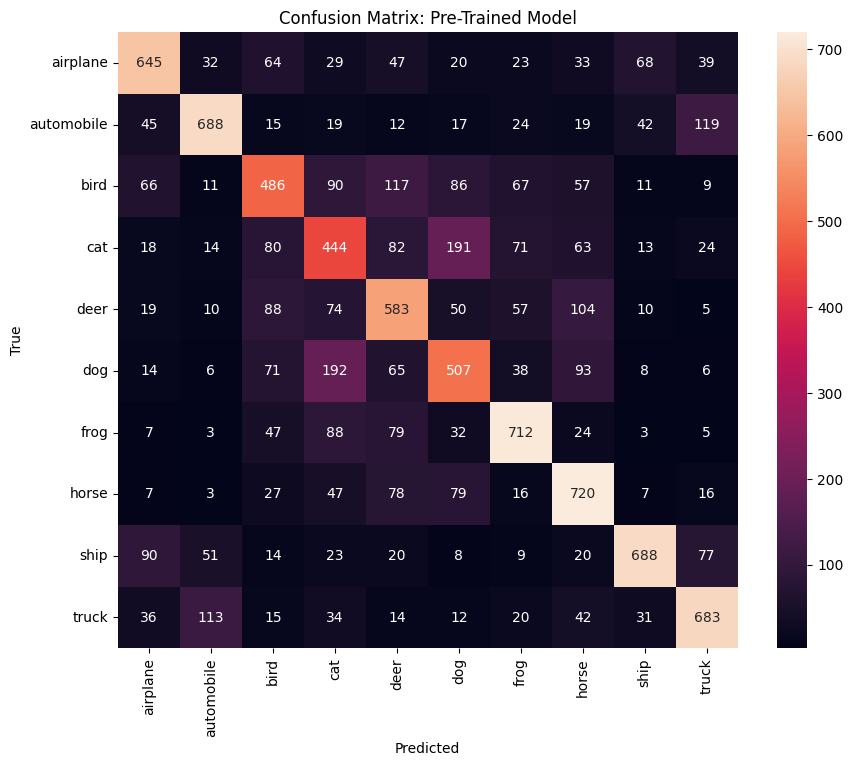

In [47]:
import seaborn as sns
cm = confusion_matrix(labels_pretrained, preds_pretrained)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Pre-Trained Model')
plt.show()

In [48]:
cr = classification_report(labels_pretrained, preds_pretrained)
print(cr)

              precision    recall  f1-score   support

           0       0.68      0.65      0.66      1000
           1       0.74      0.69      0.71      1000
           2       0.54      0.49      0.51      1000
           3       0.43      0.44      0.44      1000
           4       0.53      0.58      0.56      1000
           5       0.51      0.51      0.51      1000
           6       0.69      0.71      0.70      1000
           7       0.61      0.72      0.66      1000
           8       0.78      0.69      0.73      1000
           9       0.69      0.68      0.69      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



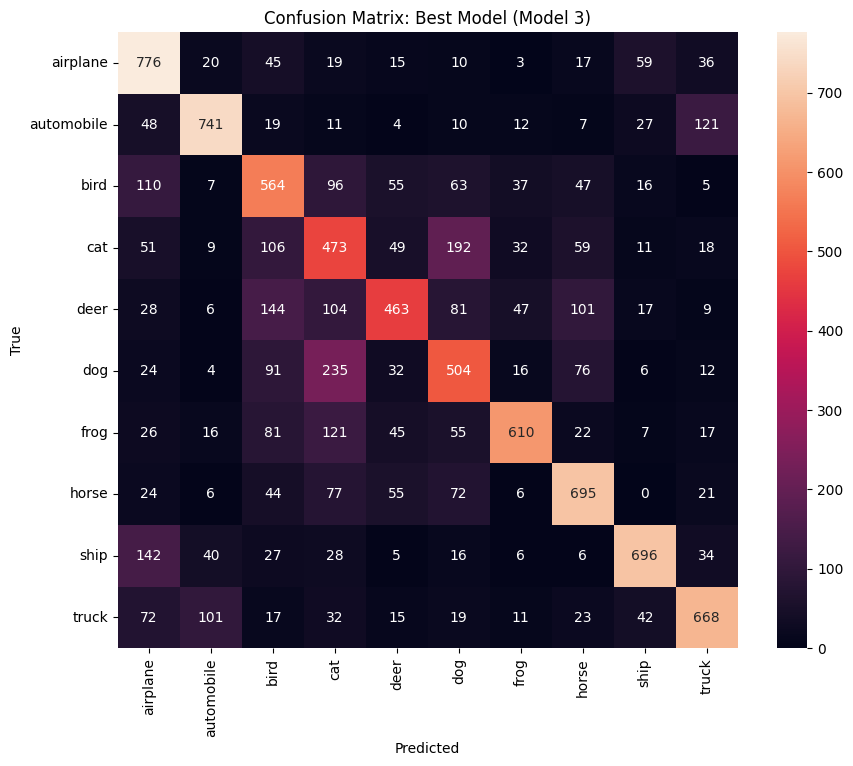

In [49]:
import seaborn as sns
cm = confusion_matrix(labels_best, preds_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Best Model (Model 3)')
plt.show()

In [50]:
cr = classification_report(labels_best, preds_best)
print(cr)

              precision    recall  f1-score   support

           0       0.60      0.78      0.67      1000
           1       0.78      0.74      0.76      1000
           2       0.50      0.56      0.53      1000
           3       0.40      0.47      0.43      1000
           4       0.63      0.46      0.53      1000
           5       0.49      0.50      0.50      1000
           6       0.78      0.61      0.69      1000
           7       0.66      0.69      0.68      1000
           8       0.79      0.70      0.74      1000
           9       0.71      0.67      0.69      1000

    accuracy                           0.62     10000
   macro avg       0.63      0.62      0.62     10000
weighted avg       0.63      0.62      0.62     10000



To get all the info needed

In [51]:
#Getting results for three models

def print_model_summary(name, history):

    final_train_accuracy = history['training_accuracy'][-1]
    final_validation_accuracy = history['validation_accuracy'][-1]

    best_val_accuracy = max(history['validation_accuracy'])
    best_epoch = history['validation_accuracy'].index(best_val_accuracy) + 1  
    
    print(f"--- {name}'s Summary ---")
    print(f'Final Training Accuracy: {final_train_accuracy:.2f}%')
    print(f'Final Validation Accuracy: {final_validation_accuracy:.2f}%')
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}% (at Epoch {best_epoch})")



In [52]:
print_model_summary("CIFAR10_LeNet", history_1)
print_model_summary("CIFAR10_model_1 (Dropout)", history_2)
print_model_summary("CIFAR10_model_2 (BatchNorm)", history_3)

--- CIFAR10_LeNet's Summary ---
Final Training Accuracy: 78.29%
Final Validation Accuracy: 58.26%
Best Validation Accuracy: 59.71% (at Epoch 15)
--- CIFAR10_model_1 (Dropout)'s Summary ---
Final Training Accuracy: 51.76%
Final Validation Accuracy: 47.70%
Best Validation Accuracy: 48.83% (at Epoch 17)
--- CIFAR10_model_2 (BatchNorm)'s Summary ---
Final Training Accuracy: 79.43%
Final Validation Accuracy: 63.14%
Best Validation Accuracy: 64.24% (at Epoch 16)


In [53]:
def training_history_plot(name, history):
    epochs = range(1, len(history['training_loss']) + 1)

    plt.figure(figsize=(12,5))

    # plotting loss
    
    plt.subplot(1,2,1)
    plt.plot(epochs, history['training_loss'], 'r-', label='Training Loss' )
    plt.plot(epochs, history['validation_loss'], 'b-', label='Validation Loss' )
    plt.title(f'{name}: Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # plotting accuracy

    plt.subplot(1,2,2)
    plt.plot(epochs, history['training_accuracy'], 'r-', label='Training Accuracy' )
    plt.plot(epochs, history['validation_accuracy'], 'b-', label='Validation Accuracy' )
    plt.title(f'{name}: Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()


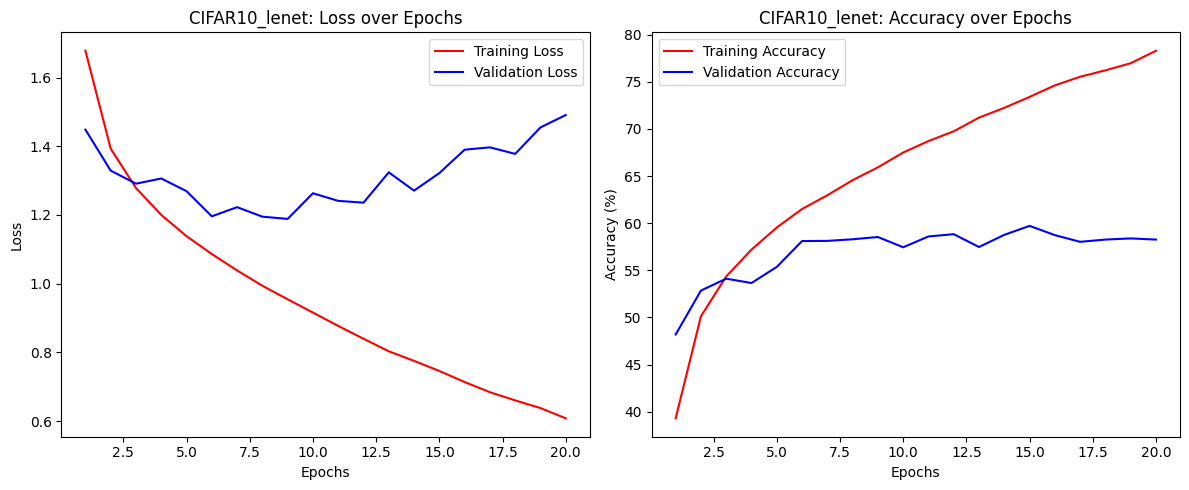

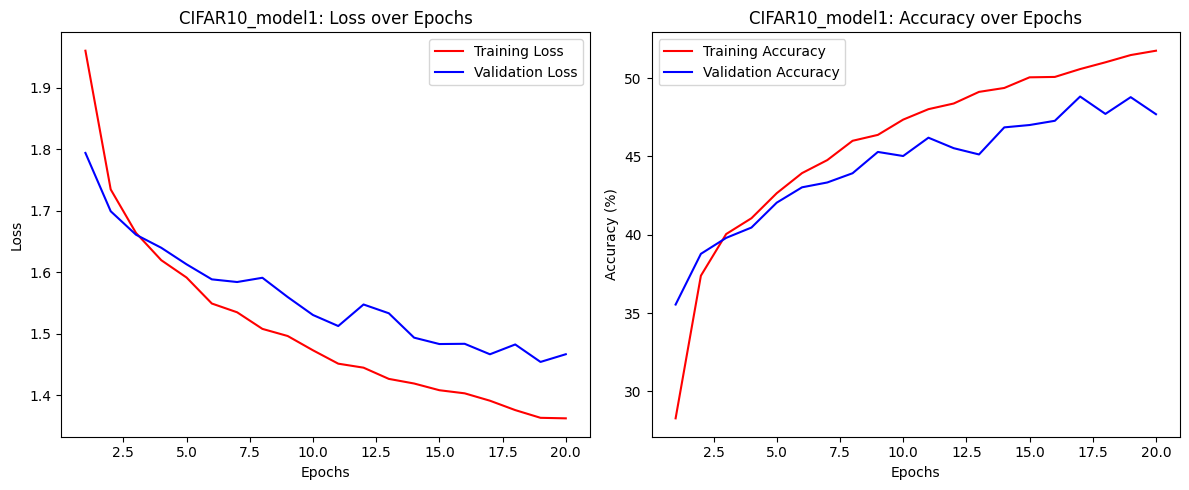

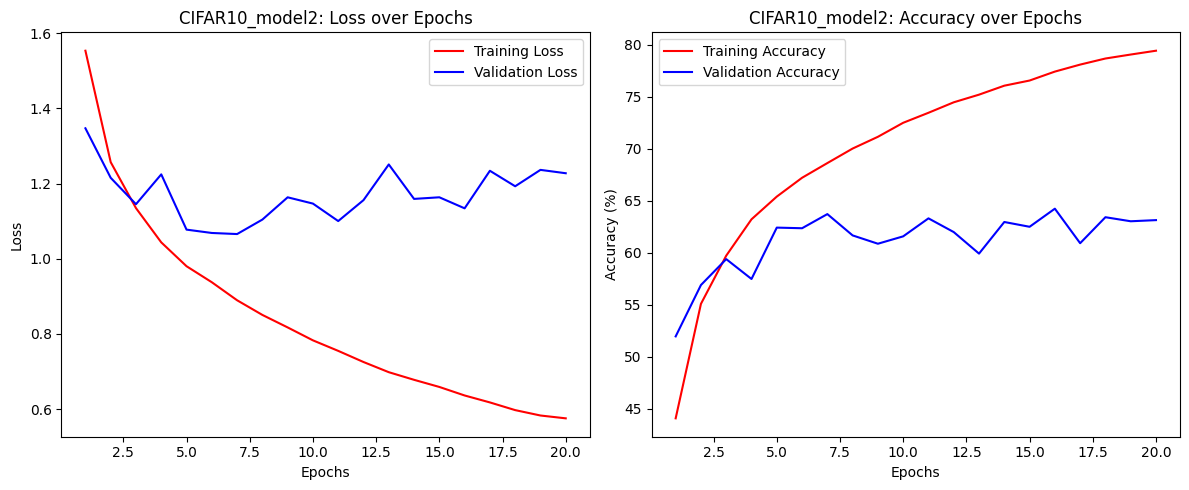

In [54]:
training_history_plot("CIFAR10_lenet", history_1)
training_history_plot("CIFAR10_model1", history_2)
training_history_plot("CIFAR10_model2", history_3)

In [ ]:
def run_full_training_validate_choice1(model, train_loader, val_loader, epochs = 20):
    current_lr = 0.001
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr  = current_lr)
    
    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": [], 'lr_history': []}
    print("---Training and Validation has started---")
    
    for epoch in range(epochs):
        
        
        if epoch % 5 == 0 and epoch > 0:
            current_lr = current_lr / 2
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
            
        history['lr_history'].append(current_lr)
        train_loss, train_accuracy = train_one_epoch(model, training_loader, optimizer, criterion)
            
        val_loss, val_accuracy = validate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")
        print(f'lr: {current_lr:.6f}')
        

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)



In [60]:
history = run_full_training_validate_choice1(CIFAR10_pretrained, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 0.4652084507107735, Training Accuracy: 83.235
Epoch 1, Validation Loss : 1.364069389078183, Validation Accuracy: 61.85000000000001
lr: 0.000500
Epoch 2, Training Loss : 0.4573053626358509, Training Accuracy: 83.5625
Epoch 2, Validation Loss : 1.4107443294205224, Validation Accuracy: 60.8
lr: 0.000500
Epoch 3, Training Loss : 0.4447816820859909, Training Accuracy: 84.05749999999999
Epoch 3, Validation Loss : 1.385155147637803, Validation Accuracy: 62.22
lr: 0.000500
Epoch 4, Training Loss : 0.44519601434469225, Training Accuracy: 83.975
Epoch 4, Validation Loss : 1.4468017715615586, Validation Accuracy: 61.19
lr: 0.000500
Epoch 5, Training Loss : 0.436619540977478, Training Accuracy: 84.0875
Epoch 5, Validation Loss : 1.473833277583503, Validation Accuracy: 60.72
lr: 0.000500
Epoch 6, Training Loss : 0.3929451425909996, Training Accuracy: 85.9825
Epoch 6, Validation Loss : 1.4582704404672495, Validation Accuracy: 62.0399

KeyboardInterrupt: 